In [1]:
import h5py
import numpy as np
import gvar as gv
import math
import lsqfit
import matplotlib.pyplot as plt
from scipy.special import kv, gamma
#import warnings
#warnings.filterwarnings('ignore', category=RuntimeWarning)

# ---------------------------------------------------------
# 1. Jackknife Statistics Helper
# ---------------------------------------------------------
def Jackknife(datalist):
    N = len(datalist)
    theta_bar = np.mean(datalist)
    theta_nminus_theta_bar = []
    for i in range(N):
        theta_n = datalist[i]
        theta_nminus_theta_bar.append(np.square(theta_n - theta_bar))
    sigma_sq = ((N-1)/N) * np.sum(theta_nminus_theta_bar)
    return theta_bar, np.sqrt(sigma_sq)

def fmt_err(mean, err):
    # Fallback for 0 or negative error
    if err <= 0:
        return f"{mean}"

    # Switch to scientific if very small/big
    if mean and (abs(mean) < 1e-3 or abs(mean) >= 1e3):
        # Calculate exponent of the mean
        exp = int(math.floor(math.log10(abs(mean))))
        mean_scaled = mean / 10**exp
        err_scaled = err / 10**exp

        # Find precision needed for exactly 2 significant digits of the error
        place = int(math.floor(math.log10(abs(err_scaled))))
        ndec = max(0, -(place - 1))

        m_str = f"{mean_scaled:.{ndec}f}"
        err_int = int(round(err_scaled * 10**ndec))
        return f"{m_str}({err_int})e{exp}"

    else:
        # Find precision needed for exactly 2 significant digits of the error
        place = int(math.floor(math.log10(abs(err))))
        ndec = max(0, -(place - 1))  # -1 gives us 2 sig figs instead of 1

        m_str = f"{mean:.{ndec}f}"
        err_int = int(round(err * 10**ndec))
        return f"{m_str}({err_int})"

def ReA2B(eta, bL, bT, a, c, d, f, k1, k2, j):
    denom = (1 + (d + c * (1 - k1/eta - k2/eta**2)) * bL**2 + d * bT**2)**j
    return a * gv.exp(-f * eta) / denom

def ImA2B(eta, bL, bT, a, c, d, f, j):
    denom = (1 + (d + c) * bL**2 + d * bT**2)**j
    return a * bL * gv.exp(-f * eta) / denom

def ReA12B(eta, bL, bT, a, c, d, f, j):
    denom = (1 + (d + c) * bL**2 + d * bT**2)**j
    return -a * gv.exp(-f * eta) / denom

def load_params_from_h5(filename):
    fitted_params = {}
    with h5py.File(filename, "r") as f:
        # 1. Load the jackknifed parameter samples
        param_group = f["jackknife_samples"]
        for key in param_group.keys():
            # Read the dataset back into a numpy array
            fitted_params[key] = param_group[key][:]

        # 2. Load the chi-square per dof array
        chi2_dof_list = f["chi2_dof"][:]

    return fitted_params, chi2_dof_list


def print_latex_table(fitted_params, chi2_dof_list, PL, bmin, etamin, etamax):
    # Calculate jackknifed means and errors for all parameters
    res = {}
    for key in fitted_params:
        mean, err = Jackknife(fitted_params[key])
        res[key] = fmt_err(mean, err)

    mean_chi2, err_chi2 = Jackknife(chi2_dof_list)
    chi2_str = fmt_err(mean_chi2, err_chi2)

    # Group parameters by Amplitude
    # (Including 'f' since it's a shared parameter in your model)
    re_params = ['a_re', 'c_re', 'd_re', 'k1_re', 'k2_re', 'j_re', 'f']
    im_params = ['a_im', 'c_im', 'd_im', 'j_im', 'f']
    a12b_params = ['a_reA12B', 'c_reA12B', 'd_reA12B', 'j_reA12B', 'f']

    # Format values as comma-separated lists
    vals_re = ", ".join([res[p] for p in re_params])
    vals_im = ", ".join([res[p] for p in im_params])
    vals_a12b = ", ".join([res[p] for p in a12b_params])

    # LaTeX representations (Raw strings handle their own backslashes)
    eq_re = r"$\frac{a e^{-f \eta}}{\left[1 + \left(d + c\left(1 - \frac{k_1}{\eta} - \frac{k_2}{\eta^2}\right)\right) b_L^2 + d b_T^2\right]^j}$"
    eq_im = r"$\frac{a b_L e^{-f \eta}}{\left[1 + (c + d) b_L^2 + d b_T^2\right]^j}$"
    eq_a12b = r"$\frac{-a e^{-f \eta}}{\left[1 + (c + d) b_L^2 + d b_T^2\right]^j}$"

    names_re = r"$\{a, c, d, k_1, k_2, j, f\}$"
    names_im = r"$\{a, c, d, j, f\}$"
    names_a12b = r"$\{a, c, d, j, f\}$"

    # Construct Markdown string (Double backslashes used here to fix the escape sequence warnings)
    md = f"\n### Simultaneous Fit with common f: \n for PL={PL}, $b_{{min}} \\ge {bmin}$, $\\eta \\in [{etamin}, {etamax}]$\n\n $\\chi^2/\\text{{DoF}}$ = {chi2_str} (Global)\n\n"
    md += "| Amplitude | Model Expression | Params List | Fitted Values |\n"
    md += "| :--- | :--- | :--- | :--- |\n"
    md += f"| $\\text{{Re}}A_{{2B}}$ | {eq_re} | {names_re} | $[{vals_re}]$ |\n"
    md += f"| $\\text{{Im}}A_{{2B}}$ | {eq_im} | {names_im} | $[{vals_im}]$ |\n"
    md += f"| $\\text{{Re}}A_{{12B}}$ | {eq_a12b} | {names_a12b} | $[{vals_a12b}]$ |\n"

    # If running in Jupyter Notebook, render it nicely:
    try:
        from IPython.display import display, Markdown
        display(Markdown(md))
    except ImportError:
        # If running in a standard terminal, just print the markdown text
        print(md)


def jackknife_axis0(arr):
    """Vectorized Jackknife: reduces axis 0 (the N_jk axis) of an
    (N_jk, ...) array. Numerically identical to calling the scalar
    Jackknife() once per column, since it performs the exact same
    mean / sum-of-squared-deviations reduction over the same N_jk
    values in the same order -- just without the Python-level loop."""
    N = arr.shape[0]
    theta_bar = np.mean(arr, axis=0)
    sigma_sq = ((N - 1) / N) * np.sum(np.square(arr - theta_bar), axis=0)
    return theta_bar, np.sqrt(sigma_sq)


def plot_fourier_transforms_A2B_A12B(fitted_params, chi2_dof_list, b2, PL, bminfit, etamin, etamax, num_points=200):
    print_latex_table(fitted_params, chi2_dof_list, PL, bminfit, etamin, etamax)

    # Setup x-axis (avoid exactly 0 to prevent division by zero in Bessel/powers)
    x_vals = np.linspace(-1, 1, num_points)

    MassN = 0.6228
    lata = 0.11403
    massterm = MassN * (197 * 0.001 / lata)

    # 1. Extract parameters as NumPy arrays
    a_re = np.array(fitted_params['a_re'])
    c_re = np.array(fitted_params['c_re']) / (PL**2)
    d_re = 1.0 + np.array(fitted_params['d_re']) * b2
    j_re = np.array(fitted_params['j_re'])

    a_im = np.array(fitted_params['a_im']) / PL
    c_im = np.array(fitted_params['c_im']) / (PL**2)
    d_im = 1.0 + np.array(fitted_params['d_im']) * b2
    j_im = np.array(fitted_params['j_im'])

    a_reA12B = -np.array(fitted_params['a_reA12B'])
    c_reA12B = np.array(fitted_params['c_reA12B']) / (PL**2)
    d_reA12B = 1.0 + np.array(fitted_params['d_reA12B']) * b2
    j_reA12B = np.array(fitted_params['j_reA12B'])

    # -- Hoisted x-independent invariants -------------------------------------
    # cd_*, term1_*, and the sqrt(cd)/sqrt(d/c) factors depend only on the
    # jackknife parameter arrays (and b2, PL), never on x. The original code
    # recomputed these once per call to calc_integrals_for_grid (x4) AND once
    # per iteration of the 200-point plotting loop (x200) -- i.e. 204x more
    # often than necessary. Computing them once here is bit-identical (same
    # floating-point operations, just not repeated) and removes essentially
    # all of the redundant scipy.special.gamma / power evaluations.
    cd_R = c_re / d_re
    term1_R = (2**(1 - j_re) * a_re * cd_R**(-0.25 - j_re/2) * d_re**(-j_re)) / gamma(j_re)
    sqrt_cd_R = np.sqrt(cd_R)

    cd_I = c_im / d_im
    term1_I = (2**(1 - j_im) * a_im * cd_I**(0.25 * (-3 - 2*j_im)) * d_im**(-j_im)) / gamma(j_im)
    sqrt_dc_I = np.sqrt(d_im / c_im)

    cd_RA12B = c_reA12B / d_reA12B
    term1_RA12B = (2**(1 - j_reA12B) * a_reA12B * cd_RA12B**(-0.25 - j_reA12B/2) * d_reA12B**(-j_reA12B)) / gamma(j_reA12B)
    sqrt_cd_RA12B = np.sqrt(cd_RA12B)

    # =========================================================================
    # NEW: Numerical Integration Section
    # =========================================================================
    print("\nComputing Numerical Integrals across Jackknife samples...")

    # Define dense integration grids (the {-inf,inf} and {-1,1} grids used to
    # be built and Bessel-evaluated here too; see below for why they're gone.)
    x_m10  = np.linspace(-1, 0, 1000)[:, None]
    x_01  = np.linspace(0, 1, 1000)[:, None]

    # Safeguard against exactly zero
    x_01[x_01 == 0] = 1e-12
    x_m10[x_m10 == 0] = 1e-12

    def raw_integrals_for_grid(x_grid):
        """Vectorized Bessel-K evaluation + trapezoidal integration over a
        given x_grid. Returns the three raw (un-combined) integrals."""
        abs_x = np.abs(x_grid)

        # ReA2B
        term2_R = abs_x**(-0.5 + j_re)
        bessel_R = kv(0.5 - j_re, abs_x / sqrt_cd_R)
        re_evals = term1_R * term2_R * bessel_R

        # ImA2B
        term2_I = x_grid * abs_x**(-1.5 + j_im)
        bessel_I = kv(1.5 - j_im, sqrt_dc_I * abs_x)
        im_evals = term1_I * term2_I * bessel_I

        # ReA12B
        term2_RA12B = abs_x**(-0.5 + j_reA12B)
        bessel_RA12B = kv(0.5 - j_reA12B, abs_x / sqrt_cd_RA12B)
        reA12B_evals = term1_RA12B * term2_RA12B * bessel_RA12B

        # Integrate (trapz sums over axis 0, leaving an array of size N_samples)
        int_re = np.trapz(re_evals, x=x_grid.flatten(), axis=0)
        int_im = np.trapz(im_evals, x=x_grid.flatten(), axis=0)
        int_reA12B = np.trapz(reA12B_evals, x=x_grid.flatten(), axis=0)

        return int_re, int_im, int_reA12B

    def derive_quantities(int_re, int_im, int_reA12B):
        f1_0 = 2 * (int_re - int_im)
        f1T_perp = -2 * int_reA12B
        sivers_ratio = massterm * f1T_perp / f1_0
        return int_re, int_im, f1_0, f1T_perp, sivers_ratio

    # {-inf, inf}: exact closed form via the Parseval identity, instead of a
    # 4000-point (x8000 samples wide) Bessel-K quadrature over [-40, 40].
    # In the {0,1} FT convention used throughout this notebook,
    #   Integral_{-inf}^{inf} Atilde(x) dx = sqrt(2*pi) * A(lambda=0)
    # and at lambda=0 the (D + C*lambda^2)^-j denominators reduce to D^-j:
    #   A_re(0)    = a_re    * d_re**(-j_re)
    #   A_reA12B(0)= a_reA12B* d_reA12B**(-j_reA12B)
    # while A_im(lambda) is odd in lambda, so A_im(0) = 0 exactly (and,
    # independently, Atilde_im(x) is itself odd in x, so its integral over
    # the symmetric range is exactly zero either way).
    int_inf_re     = np.sqrt(2 * np.pi) * a_re * d_re**(-j_re)
    int_inf_im     = np.zeros_like(a_im)
    int_inf_reA12B = np.sqrt(2 * np.pi) * a_reA12B * d_reA12B**(-j_reA12B)
    res_inf = derive_quantities(int_inf_re, int_inf_im, int_inf_reA12B)

    raw_m10 = raw_integrals_for_grid(x_m10)
    raw_01  = raw_integrals_for_grid(x_01)
    res_m10 = derive_quantities(*raw_m10)
    res_01  = derive_quantities(*raw_01)

    # {-1, 1}: exact sum of the two adjacent sub-integrals just computed,
    # instead of a 4th independent 1000-point Bessel-K quadrature over the
    # same interval (Integral_{-1}^{1} = Integral_{-1}^{0} + Integral_{0}^{1}).
    raw_11 = tuple(a + b for a, b in zip(raw_m10, raw_01))
    res_11 = derive_quantities(*raw_11)

    def format_jk(data):
        mean, err = Jackknife(data)
        return fmt_err(mean, err)


    row1 = [format_jk(res_inf[0]), format_jk(res_11[0]), format_jk(res_m10[0]), format_jk(res_01[0])]
    row2 = [format_jk(res_inf[1]), format_jk(res_11[1]), format_jk(res_m10[1]), format_jk(res_01[1])]
    row3 = [format_jk(res_inf[2]), format_jk(res_11[2]), format_jk(res_m10[2]), format_jk(res_01[2])]
    row4 = [format_jk(res_inf[3]), format_jk(res_11[3]), format_jk(res_m10[3]), format_jk(res_01[3])]
    row5 = [format_jk(res_inf[4]), format_jk(res_11[4]), format_jk(res_m10[4]), format_jk(res_01[4])]

    # Build the Markdown table
    md_int = "\n### Numerical Integration of Fourier Transforms\n\n"
    md_int += "| Integral | $\\{-\\infty, \\infty\\}$ | $\\{-1, 1\\}$ | $\\{-1, 0\\}$ | $\\{0, 1\\}$ |\n"
    md_int += "| :--- | :--- | :--- | :--- | :--- |\n"
    md_int += f"| $\\int dx \\tilde{{A}}_{{2B}}^{{\\text{{Re}}}}$ | {row1[0]} | {row1[1]} | {row1[2]} | {row1[3]} |\n"
    md_int += f"| $\\int dx (i\\tilde{{A}}_{{2B}}^{{\\text{{Im}}}})$ | {row2[0]} | {row2[1]} | {row2[2]} | {row2[3]} |\n"
    md_int += f"| $\\tilde{{f}}_1^{{(0)}} = 2\\int dx (\\tilde{{A}}_{{2B}}^{{\\text{{Re}}}} - i\\tilde{{A}}_{{2B}}^{{\\text{{Im}}}})$ | {row3[0]} | {row3[1]} | {row3[2]} | {row3[3]} |\n"
    md_int += f"| $\\tilde{{f}}_{{1T}}^{{\\perp(1)}} = -2\\int dx \\tilde{{A}}_{{12B}}$ | {row4[0]} | {row4[1]} | {row4[2]} | {row4[3]} |\n"
    md_int += f"| $m_N \\frac{{\\tilde{{f}}_{{1T}}^{{\\perp(1)}}}}{{\\tilde{{f}}_1^{{(0)}}}}$ | {row5[0]} | {row5[1]} | {row5[2]} | {row5[3]} |\n"

    try:
        from IPython.display import display, Markdown
        display(Markdown(md_int))
    except ImportError:
        print(md_int)

    # =========================================================================
    # 2. Plotting Section -- fully vectorized over x_vals (same arithmetic as
    #    the previous per-x Python loop, evaluated in one broadcasted shot
    #    instead of 200 sequential scalar iterations with list.append()).
    # =========================================================================
    print("\nEvaluating Fourier transforms and applying Jackknife for Plotting...")

    # Same zero-guard as before, applied elementwise instead of per-iteration
    x_safe = x_vals.copy()
    x_safe[x_safe == 0] = 1e-12
    abs_x_safe = np.abs(x_safe)

    xr  = x_safe[None, :]      # (1, num_points)
    axr = abs_x_safe[None, :]  # (1, num_points)

    re_evals_all = (term1_R[:, None]
                    * axr**(-0.5 + j_re[:, None])
                    * kv(0.5 - j_re[:, None], axr / sqrt_cd_R[:, None]))

    im_evals_all = (term1_I[:, None]
                    * (xr * axr**(-1.5 + j_im[:, None]))
                    * kv(1.5 - j_im[:, None], sqrt_dc_I[:, None] * axr))

    reA12B_evals_all = (term1_RA12B[:, None]
                        * axr**(-0.5 + j_reA12B[:, None])
                        * kv(0.5 - j_reA12B[:, None], axr / sqrt_cd_RA12B[:, None]))

    re_mean, re_err = jackknife_axis0(re_evals_all)
    im_mean, im_err = jackknife_axis0(im_evals_all)
    full_mean, full_err = jackknife_axis0(2 * (re_evals_all - im_evals_all))
    reA12B_mean, reA12B_err = jackknife_axis0(-2 * reA12B_evals_all)

    siv_ratio_all = (-massterm * reA12B_evals_all) / (re_evals_all - im_evals_all)
    SiverseShift_mean, SiverseShift_err = jackknife_axis0(siv_ratio_all)
    xSiverseShift_mean, xSiverseShift_err = jackknife_axis0(xr * siv_ratio_all)

    # 4. Plotting
    fig, ((ax1, ax2, ax3), (ax4, ax5, ax6)) = plt.subplots(2, 3, figsize=(14, 8))

    # Real Plot
    ax1.plot(x_vals, re_mean, color='blue', label='ReA2B Mean')
    ax1.fill_between(x_vals, re_mean - re_err, re_mean + re_err, color='blue', alpha=0.3)
    ax1.set_title(f'$\\tilde{{A}}_{{2B}}^{{Re}}$ ($P_L$={PL}, $b^2$={b2})')
    ax1.set_xlabel('$x$')
    ax1.set_ylabel('$\\tilde{{A}}_{{2B}}^{{Re}}$')
    ax1.grid(True, linestyle='--', alpha=0.6)

    # Imaginary Plot
    ax2.plot(x_vals, im_mean, color='red', label='ImA2B Mean')
    ax2.fill_between(x_vals, im_mean - im_err, im_mean + im_err, color='red', alpha=0.3)
    ax2.set_title(f'$i\\tilde{{A}}_{{2B}}^{{Im}}$ ($P_L$={PL}, $b^2$={b2})')
    ax2.set_xlabel('$x$')
    ax2.set_ylabel('$i\\tilde{{A}}_{{2B}}^{{Im}}$')
    ax2.grid(True, linestyle='--', alpha=0.6)

    # Full f1 Plot
    ax3.plot(x_vals, full_mean, color='green', label='A2B Mean')
    ax3.fill_between(x_vals, full_mean - full_err, full_mean + full_err, color='green', alpha=0.3)
    ax3.set_title(f'$\\tilde{{f}}_{{1}}^{{(0)}}=2\\tilde{{A}}_{{2B}}$ ($P_L$={PL}, $b^2$={b2})')
    ax3.set_xlabel('$x$')
    ax3.set_ylabel('$\\tilde{{f}}_{{1}}^{{(0)}}$')
    ax3.grid(True, linestyle='--', alpha=0.6)

    # A12B Plot
    ax4.plot(x_vals, reA12B_mean, color='blue')
    ax4.fill_between(x_vals, reA12B_mean - reA12B_err, reA12B_mean + reA12B_err, color='blue', alpha=0.3)
    ax4.set_title(f'$\\tilde{{f}}_{{1}}^{{\\perp(1)}}=-2\\tilde{{A}}_{{12B}}$ ($P_L$={PL}, $b^2$={b2})')
    ax4.set_xlabel('$x$')
    ax4.set_ylabel('$\\tilde{{f}}_{{1}}^{{\\perp(1)}}$')
    ax4.grid(True, linestyle='--', alpha=0.6)

    # Create mask for x values from 0 to 1
    mask = x_vals >= 0

    # Sivers Shift Plot (0 to 1)
    ax5.plot(x_vals[mask], SiverseShift_mean[mask], color='blue')
    ax5.fill_between(x_vals[mask], SiverseShift_mean[mask] - SiverseShift_err[mask],
                     SiverseShift_mean[mask] + SiverseShift_err[mask], color='blue', alpha=0.3)
    ax5.set_title(f'$\\langle k_{{y}} \\rangle_{{TU}}$(GeV) ($P_L$={PL}, $b^2$={b2})')
    ax5.set_xlabel('$x$')
    ax5.set_ylabel('$\\langle k_{{y}} \\rangle_{{TU}}$(GeV)')
    ax5.grid(True, linestyle='--', alpha=0.6)

    # x*Sivers Shift Plot (0 to 1)
    ax6.plot(x_vals[mask], xSiverseShift_mean[mask], color='blue')
    ax6.fill_between(x_vals[mask], xSiverseShift_mean[mask] - xSiverseShift_err[mask],
                     xSiverseShift_mean[mask] + xSiverseShift_err[mask], color='blue', alpha=0.3)
    ax6.set_title(f'$x\\langle k_{{y}} \\rangle_{{TU}}$(GeV) ($P_L$={PL}, $b^2$={b2})')
    ax6.set_xlabel('$x$')
    ax6.set_ylabel('$x\\langle k_{{y}} \\rangle_{{TU}}$(GeV)')
    ax6.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    param_keys_str = "-".join(fitted_params.keys())
    file_name = f"SimulFitCovMatrix-A12B-A2B-FT-{param_keys_str}__bmin{bminfit}_eta{etamin}{etamax}_PL{PL}.pdf"
    plt.savefig(file_name, format='pdf', bbox_inches='tight')
    plt.show()

    return



### Simultaneous Fit with common f: 
 for PL=-1, $b_{min} \ge 3$, $\eta \in [6, 10]$

 $\chi^2/\text{DoF}$ = 1.85(10) (Global)

| Amplitude | Model Expression | Params List | Fitted Values |
| :--- | :--- | :--- | :--- |
| $\text{Re}A_{2B}$ | $\frac{a e^{-f \eta}}{\left[1 + \left(d + c\left(1 - \frac{k_1}{\eta} - \frac{k_2}{\eta^2}\right)\right) b_L^2 + d b_T^2\right]^j}$ | $\{a, c, d, k_1, k_2, j, f\}$ | $[3.863(11), 0.336(40), 0.1630(74), 12.288(23), -36.1965(45), 1.627(25), 0.4702(46)]$ |
| $\text{Im}A_{2B}$ | $\frac{a b_L e^{-f \eta}}{\left[1 + (c + d) b_L^2 + d b_T^2\right]^j}$ | $\{a, c, d, j, f\}$ | $[0.267(13), 0.2253(69), 0.2205(66), 1.108(21), 0.4702(46)]$ |
| $\text{Re}A_{12B}$ | $\frac{-a e^{-f \eta}}{\left[1 + (c + d) b_L^2 + d b_T^2\right]^j}$ | $\{a, c, d, j, f\}$ | $[0.658(22), 0.0773(46), 0.0747(43), 2.0054(90), 0.4702(46)]$ |



Computing Numerical Integrals across Jackknife samples...



### Numerical Integration of Fourier Transforms

| Integral | $\{-\infty, \infty\}$ | $\{-1, 1\}$ | $\{-1, 0\}$ | $\{0, 1\}$ |
| :--- | :--- | :--- | :--- | :--- |
| $\int dx \tilde{A}_{2B}^{\text{Re}}$ | 2.228(59) | 1.955(73) | 0.977(36) | 0.977(36) |
| $\int dx (i\tilde{A}_{2B}^{\text{Im}})$ | 0.0 | -5.1(52)e-6 | 0.307(15) | -0.307(15) |
| $\tilde{f}_1^{(0)} = 2\int dx (\tilde{A}_{2B}^{\text{Re}} - i\tilde{A}_{2B}^{\text{Im}})$ | 4.46(12) | 3.91(15) | 1.342(64) | 2.568(90) |
| $\tilde{f}_{1T}^{\perp(1)} = -2\int dx \tilde{A}_{12B}$ | 1.176(58) | 1.138(58) | 0.569(29) | 0.569(29) |
| $m_N \frac{\tilde{f}_{1T}^{\perp(1)}}{\tilde{f}_1^{(0)}}$ | 0.284(14) | 0.313(18) | 0.456(29) | 0.238(13) |



Evaluating Fourier transforms and applying Jackknife for Plotting...


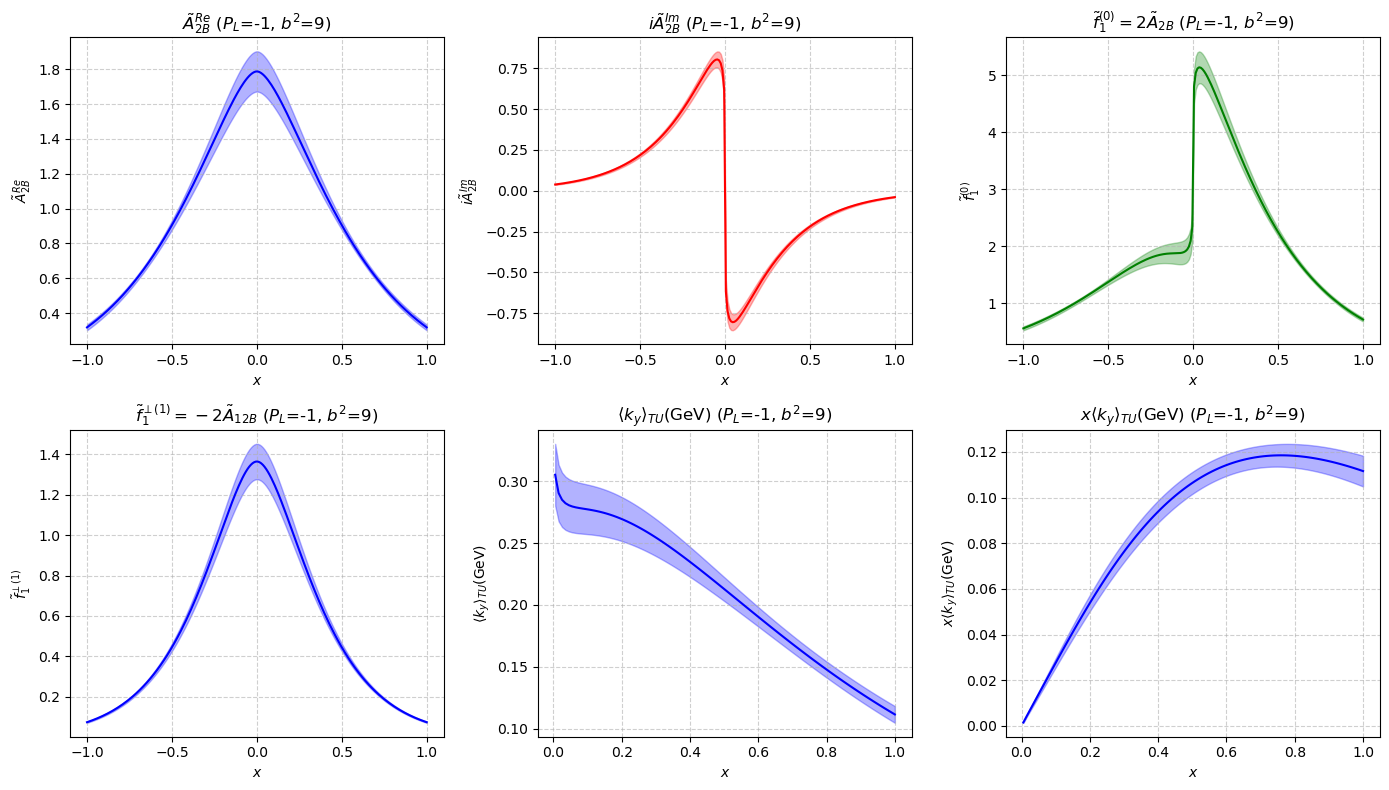

In [2]:
b2 = 9
PL = -1
bminfit = 3
etamin = 6
etamax = 10
#sivers_TMD_PhD_project/save_h5_A12B_A2B/SimultaniousFit/FitParams_SimulFit_f_A2BRe_cetasq_A2BIm_A12BRe_bmin3_eta610_PL-4.h5
fitted_params, chi2_dof_list = load_params_from_h5(f"/Users/hariprashadravikumar/sivers_TMD_PhD_project/save_h5_A12B_A2B/SimultaniousFit/FitParams_SimulFit_f_A2BRe_cetasq_A2BIm_A12BRe_bmin{bminfit}_eta{etamin}{etamax}_PL{PL}.h5")
plot_fourier_transforms_A2B_A12B(fitted_params, chi2_dof_list, b2, PL, bminfit, etamin, etamax)



### Simultaneous Fit with common f: 
 for PL=-1, $b_{min} \ge 3$, $\eta \in [6, 10]$

 $\chi^2/\text{DoF}$ = 1.85(10) (Global)

| Amplitude | Model Expression | Params List | Fitted Values |
| :--- | :--- | :--- | :--- |
| $\text{Re}A_{2B}$ | $\frac{a e^{-f \eta}}{\left[1 + \left(d + c\left(1 - \frac{k_1}{\eta} - \frac{k_2}{\eta^2}\right)\right) b_L^2 + d b_T^2\right]^j}$ | $\{a, c, d, k_1, k_2, j, f\}$ | $[3.863(11), 0.336(40), 0.1630(74), 12.288(23), -36.1965(45), 1.627(25), 0.4702(46)]$ |
| $\text{Im}A_{2B}$ | $\frac{a b_L e^{-f \eta}}{\left[1 + (c + d) b_L^2 + d b_T^2\right]^j}$ | $\{a, c, d, j, f\}$ | $[0.267(13), 0.2253(69), 0.2205(66), 1.108(21), 0.4702(46)]$ |
| $\text{Re}A_{12B}$ | $\frac{-a e^{-f \eta}}{\left[1 + (c + d) b_L^2 + d b_T^2\right]^j}$ | $\{a, c, d, j, f\}$ | $[0.658(22), 0.0773(46), 0.0747(43), 2.0054(90), 0.4702(46)]$ |



Computing Numerical Integrals across Jackknife samples...



### Numerical Integration of Fourier Transforms

| Integral | $\{-\infty, \infty\}$ | $\{-1, 1\}$ | $\{-1, 0\}$ | $\{0, 1\}$ |
| :--- | :--- | :--- | :--- | :--- |
| $\int dx \tilde{A}_{2B}^{\text{Re}}$ | 0.2641(89) | 0.2606(91) | 0.1303(46) | 0.1303(46) |
| $\int dx (i\tilde{A}_{2B}^{\text{Im}})$ | 0.0 | -5.1(52)e-6 | 0.1358(76) | -0.1358(76) |
| $\tilde{f}_1^{(0)} = 2\int dx (\tilde{A}_{2B}^{\text{Re}} - i\tilde{A}_{2B}^{\text{Im}})$ | 0.528(18) | 0.521(18) | -0.011(14) | 0.532(21) |
| $\tilde{f}_{1T}^{\perp(1)} = -2\int dx \tilde{A}_{12B}$ | 0.146(13) | 0.146(13) | 0.0728(66) | 0.0728(66) |
| $m_N \frac{\tilde{f}_{1T}^{\perp(1)}}{\tilde{f}_1^{(0)}}$ | 0.297(27) | 0.300(27) | -7.2(92) | 0.147(14) |



Evaluating Fourier transforms and applying Jackknife for Plotting...


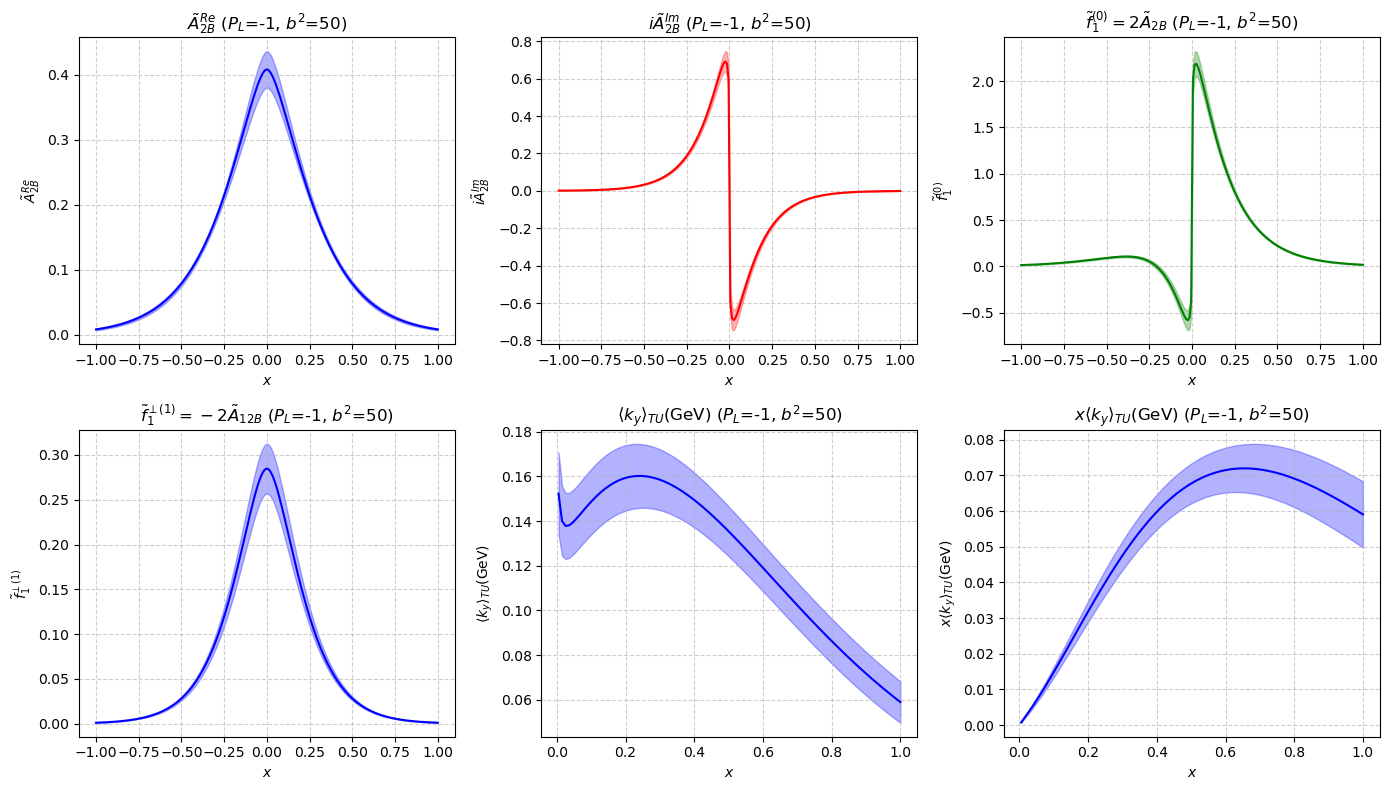

In [3]:
b2 = 50
PL = -1
bminfit = 3
etamin = 6
etamax = 10
#sivers_TMD_PhD_project/save_h5_A12B_A2B/SimultaniousFit/FitParams_SimulFit_f_A2BRe_cetasq_A2BIm_A12BRe_bmin3_eta610_PL-4.h5
fitted_params, chi2_dof_list = load_params_from_h5(f"/Users/hariprashadravikumar/sivers_TMD_PhD_project/save_h5_A12B_A2B/SimultaniousFit/FitParams_SimulFit_f_A2BRe_cetasq_A2BIm_A12BRe_bmin{bminfit}_eta{etamin}{etamax}_PL{PL}.h5")
plot_fourier_transforms_A2B_A12B(fitted_params, chi2_dof_list, b2, PL, bminfit, etamin, etamax)



### Simultaneous Fit with common f: 
 for PL=-2, $b_{min} \ge 3$, $\eta \in [6, 10]$

 $\chi^2/\text{DoF}$ = 1.197(85) (Global)

| Amplitude | Model Expression | Params List | Fitted Values |
| :--- | :--- | :--- | :--- |
| $\text{Re}A_{2B}$ | $\frac{a e^{-f \eta}}{\left[1 + \left(d + c\left(1 - \frac{k_1}{\eta} - \frac{k_2}{\eta^2}\right)\right) b_L^2 + d b_T^2\right]^j}$ | $\{a, c, d, k_1, k_2, j, f\}$ | $[3.9833(80), 0.166(35), 0.1020(46), 12.305(14), -36.1919(27), 2.061(20), 0.5357(66)]$ |
| $\text{Im}A_{2B}$ | $\frac{a b_L e^{-f \eta}}{\left[1 + (c + d) b_L^2 + d b_T^2\right]^j}$ | $\{a, c, d, j, f\}$ | $[0.368(12), 0.1346(69), 0.1305(67), 1.141(20), 0.5357(66)]$ |
| $\text{Re}A_{12B}$ | $\frac{-a e^{-f \eta}}{\left[1 + (c + d) b_L^2 + d b_T^2\right]^j}$ | $\{a, c, d, j, f\}$ | $[0.632(19), 0.0769(54), 0.0741(52), 2.0141(69), 0.5357(66)]$ |



Computing Numerical Integrals across Jackknife samples...



### Numerical Integration of Fourier Transforms

| Integral | $\{-\infty, \infty\}$ | $\{-1, 1\}$ | $\{-1, 0\}$ | $\{0, 1\}$ |
| :--- | :--- | :--- | :--- | :--- |
| $\int dx \tilde{A}_{2B}^{\text{Re}}$ | 2.61(10) | 2.59(11) | 1.297(54) | 1.297(54) |
| $\int dx (i\tilde{A}_{2B}^{\text{Im}})$ | 0.0 | -5.8(56)e-6 | 0.645(33) | -0.645(33) |
| $\tilde{f}_1^{(0)} = 2\int dx (\tilde{A}_{2B}^{\text{Re}} - i\tilde{A}_{2B}^{\text{Im}})$ | 5.22(21) | 5.19(22) | 1.304(86) | 3.89(16) |
| $\tilde{f}_{1T}^{\perp(1)} = -2\int dx \tilde{A}_{12B}$ | 1.131(68) | 1.130(68) | 0.565(34) | 0.565(34) |
| $m_N \frac{\tilde{f}_{1T}^{\perp(1)}}{\tilde{f}_1^{(0)}}$ | 0.233(14) | 0.234(14) | 0.466(36) | 0.1565(95) |



Evaluating Fourier transforms and applying Jackknife for Plotting...


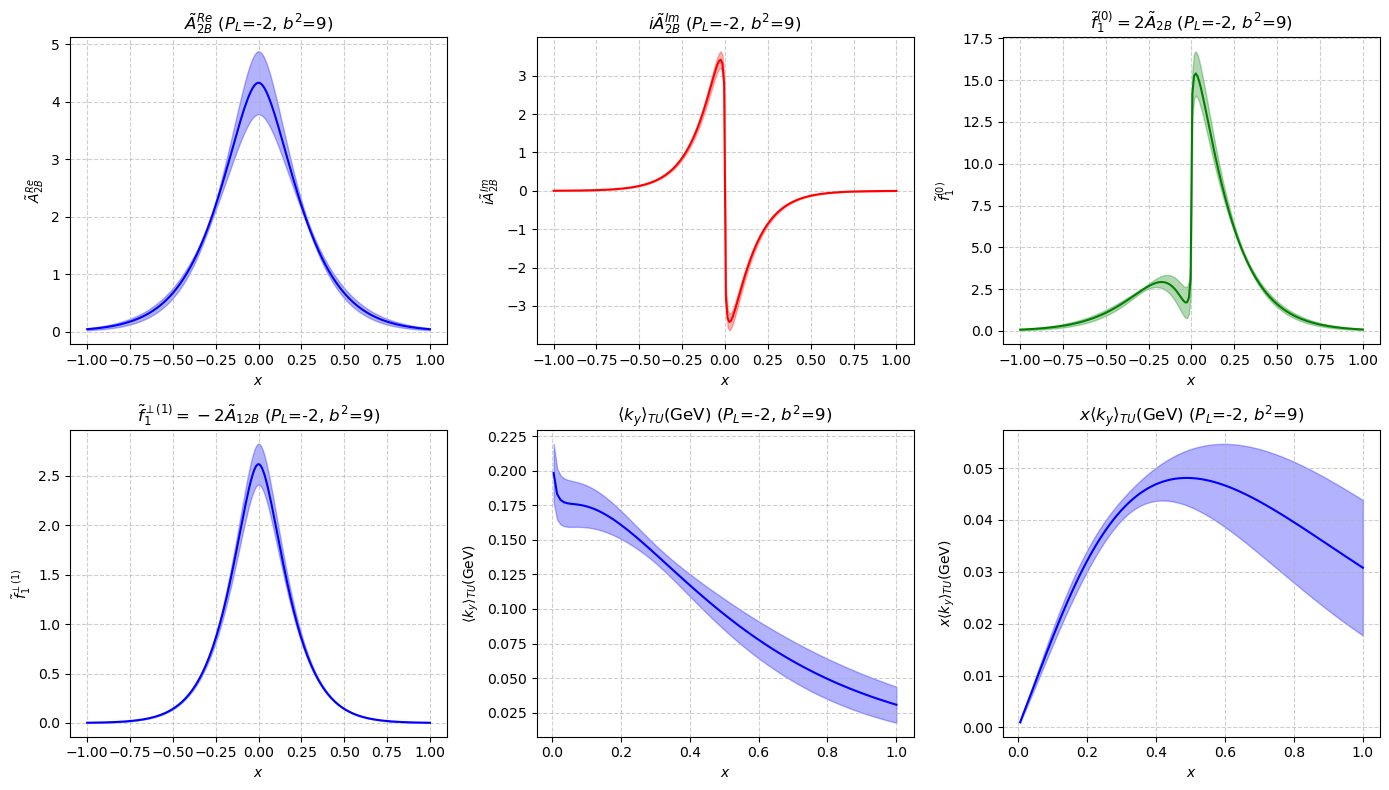

In [4]:
b2 = 9
PL = -2
bminfit = 3
etamin = 6
etamax = 10
fitted_params, chi2_dof_list = load_params_from_h5(f"/Users/hariprashadravikumar/sivers_TMD_PhD_project/save_h5_A12B_A2B/SimultaniousFit/FitParams_SimulFit_f_A2BRe_cetasq_A2BIm_A12BRe_bmin{bminfit}_eta{etamin}{etamax}_PL{PL}.h5")
plot_fourier_transforms_A2B_A12B(fitted_params, chi2_dof_list, b2, PL, bminfit, etamin, etamax)



### Simultaneous Fit with common f: 
 for PL=-3, $b_{min} \ge 3$, $\eta \in [6, 10]$

 $\chi^2/\text{DoF}$ = 0.712(66) (Global)

| Amplitude | Model Expression | Params List | Fitted Values |
| :--- | :--- | :--- | :--- |
| $\text{Re}A_{2B}$ | $\frac{a e^{-f \eta}}{\left[1 + \left(d + c\left(1 - \frac{k_1}{\eta} - \frac{k_2}{\eta^2}\right)\right) b_L^2 + d b_T^2\right]^j}$ | $\{a, c, d, k_1, k_2, j, f\}$ | $[4.0061(31), 0.45(12), 0.136(11), 12.284(11), -36.1973(19), 2.085(10), 0.540(15)]$ |
| $\text{Im}A_{2B}$ | $\frac{a b_L e^{-f \eta}}{\left[1 + (c + d) b_L^2 + d b_T^2\right]^j}$ | $\{a, c, d, j, f\}$ | $[0.328(11), 0.163(15), 0.147(13), 1.057(15), 0.540(15)]$ |
| $\text{Re}A_{12B}$ | $\frac{-a e^{-f \eta}}{\left[1 + (c + d) b_L^2 + d b_T^2\right]^j}$ | $\{a, c, d, j, f\}$ | $[0.569(13), 0.100(17), 0.094(16), 1.9969(49), 0.540(15)]$ |



Computing Numerical Integrals across Jackknife samples...



### Numerical Integration of Fourier Transforms

| Integral | $\{-\infty, \infty\}$ | $\{-1, 1\}$ | $\{-1, 0\}$ | $\{0, 1\}$ |
| :--- | :--- | :--- | :--- | :--- |
| $\int dx \tilde{A}_{2B}^{\text{Re}}$ | 1.90(17) | 1.89(18) | 0.946(88) | 0.946(88) |
| $\int dx (i\tilde{A}_{2B}^{\text{Im}})$ | 0.0 | -4.4(32)e-4 | 0.588(57) | -0.588(57) |
| $\tilde{f}_1^{(0)} = 2\int dx (\tilde{A}_{2B}^{\text{Re}} - i\tilde{A}_{2B}^{\text{Im}})$ | 3.81(34) | 3.78(35) | 0.72(14) | 3.07(26) |
| $\tilde{f}_{1T}^{\perp(1)} = -2\int dx \tilde{A}_{12B}$ | 0.84(13) | 0.84(13) | 0.418(64) | 0.418(64) |
| $m_N \frac{\tilde{f}_{1T}^{\perp(1)}}{\tilde{f}_1^{(0)}}$ | 0.236(32) | 0.238(32) | 0.63(13) | 0.147(20) |



Evaluating Fourier transforms and applying Jackknife for Plotting...


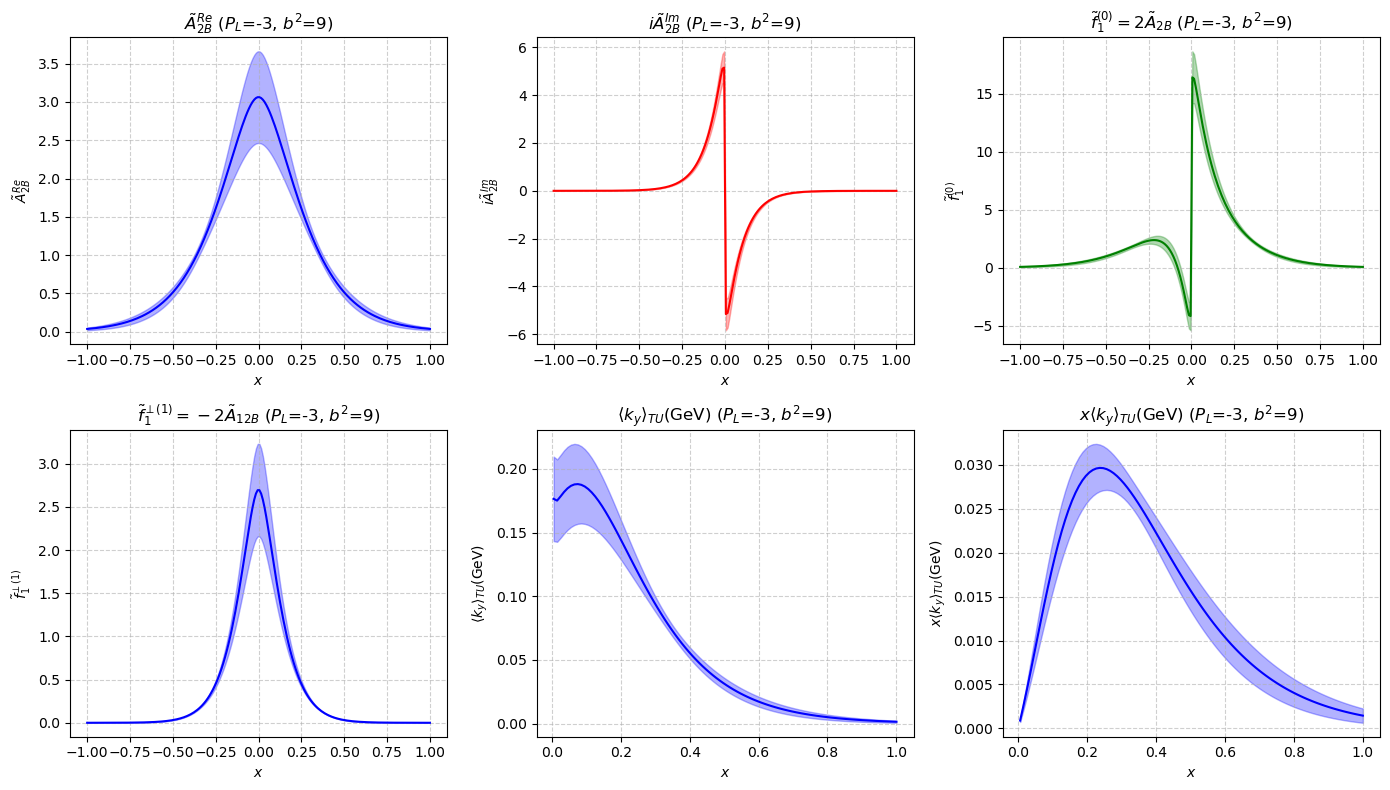

In [5]:
b2 = 9
PL = -3
bminfit = 3
etamin = 6
etamax = 10
fitted_params, chi2_dof_list = load_params_from_h5(f"/Users/hariprashadravikumar/sivers_TMD_PhD_project/save_h5_A12B_A2B/SimultaniousFit/FitParams_SimulFit_f_A2BRe_cetasq_A2BIm_A12BRe_bmin{bminfit}_eta{etamin}{etamax}_PL{PL}.h5")
plot_fourier_transforms_A2B_A12B(fitted_params, chi2_dof_list, b2, PL, bminfit, etamin, etamax)



### Simultaneous Fit with common f: 
 for PL=-4, $b_{min} \ge 3$, $\eta \in [6, 10]$

 $\chi^2/\text{DoF}$ = 0.434(51) (Global)

| Amplitude | Model Expression | Params List | Fitted Values |
| :--- | :--- | :--- | :--- |
| $\text{Re}A_{2B}$ | $\frac{a e^{-f \eta}}{\left[1 + \left(d + c\left(1 - \frac{k_1}{\eta} - \frac{k_2}{\eta^2}\right)\right) b_L^2 + d b_T^2\right]^j}$ | $\{a, c, d, k_1, k_2, j, f\}$ | $[4.0086(15), 0.27(21), 0.122(13), 12.2751(58), -36.19925(89), 2.0654(56), 0.577(19)]$ |
| $\text{Im}A_{2B}$ | $\frac{a b_L e^{-f \eta}}{\left[1 + (c + d) b_L^2 + d b_T^2\right]^j}$ | $\{a, c, d, j, f\}$ | $[0.269(13), 0.264(47), 0.196(14), 1.0084(79), 0.577(19)]$ |
| $\text{Re}A_{12B}$ | $\frac{-a e^{-f \eta}}{\left[1 + (c + d) b_L^2 + d b_T^2\right]^j}$ | $\{a, c, d, j, f\}$ | $[0.5824(55), 0.116(19), 0.102(18), 2.0059(34), 0.577(19)]$ |



Computing Numerical Integrals across Jackknife samples...



### Numerical Integration of Fourier Transforms

| Integral | $\{-\infty, \infty\}$ | $\{-1, 1\}$ | $\{-1, 0\}$ | $\{0, 1\}$ |
| :--- | :--- | :--- | :--- | :--- |
| $\int dx \tilde{A}_{2B}^{\text{Re}}$ | 2.18(26) | 2.18(26) | 1.09(13) | 1.09(13) |
| $\int dx (i\tilde{A}_{2B}^{\text{Im}})$ | 0.0 | -0.0034(20) | 0.382(64) | -0.386(66) |
| $\tilde{f}_1^{(0)} = 2\int dx (\tilde{A}_{2B}^{\text{Re}} - i\tilde{A}_{2B}^{\text{Im}})$ | 4.35(52) | 4.36(52) | 1.41(29) | 2.95(29) |
| $\tilde{f}_{1T}^{\perp(1)} = -2\int dx \tilde{A}_{12B}$ | 0.79(14) | 0.79(14) | 0.394(69) | 0.394(69) |
| $m_N \frac{\tilde{f}_{1T}^{\perp(1)}}{\tilde{f}_1^{(0)}}$ | 0.195(37) | 0.195(37) | 0.301(73) | 0.144(27) |



Evaluating Fourier transforms and applying Jackknife for Plotting...


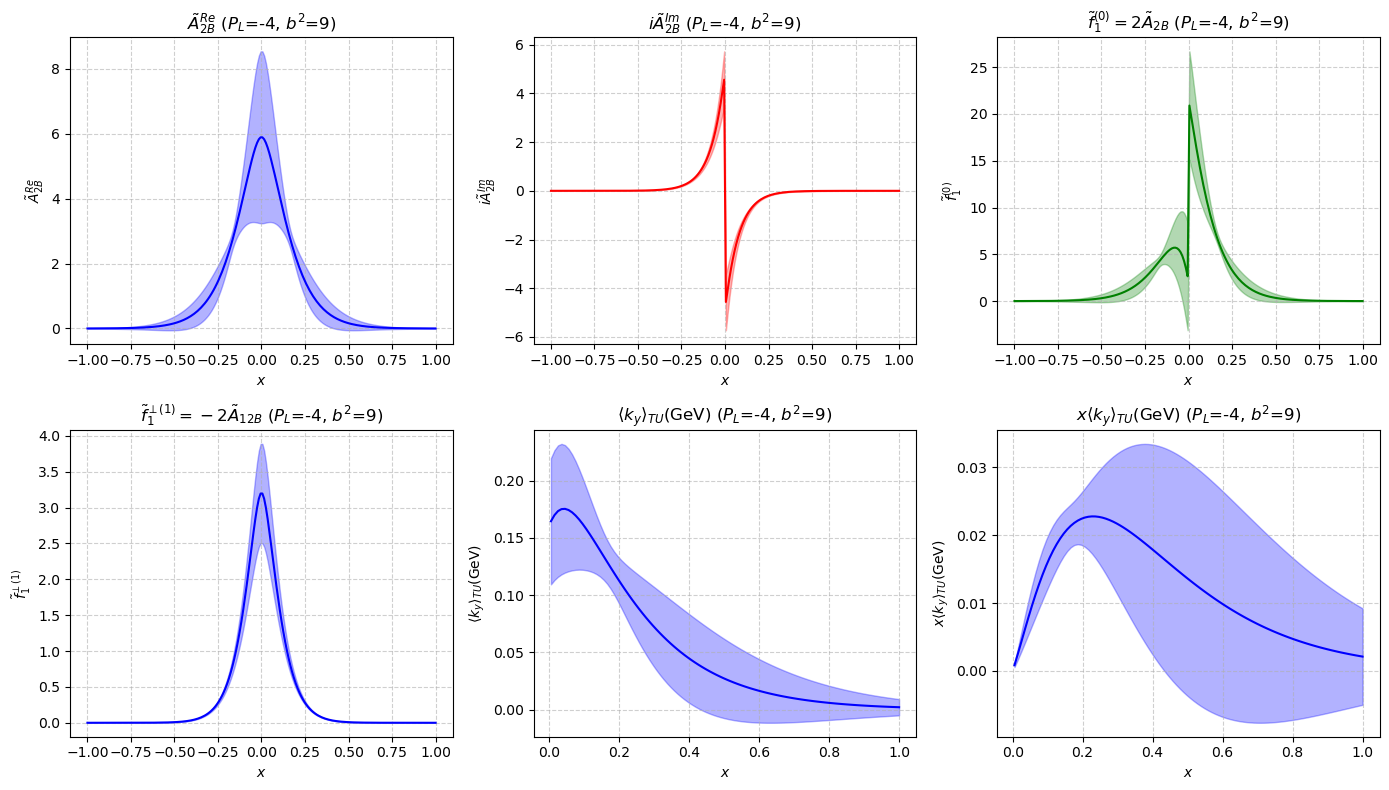

In [6]:
b2 = 9
PL = -4
bminfit = 3
etamin = 6
etamax = 10
fitted_params, chi2_dof_list = load_params_from_h5(f"/Users/hariprashadravikumar/sivers_TMD_PhD_project/save_h5_A12B_A2B/SimultaniousFit/FitParams_SimulFit_f_A2BRe_cetasq_A2BIm_A12BRe_bmin{bminfit}_eta{etamin}{etamax}_PL{PL}.h5")
plot_fourier_transforms_A2B_A12B(fitted_params, chi2_dof_list, b2, PL, bminfit, etamin, etamax)



### Simultaneous Fit with common f: 
 for PL=-4, $b_{min} \ge 3$, $\eta \in [6, 10]$

 $\chi^2/\text{DoF}$ = 0.434(51) (Global)

| Amplitude | Model Expression | Params List | Fitted Values |
| :--- | :--- | :--- | :--- |
| $\text{Re}A_{2B}$ | $\frac{a e^{-f \eta}}{\left[1 + \left(d + c\left(1 - \frac{k_1}{\eta} - \frac{k_2}{\eta^2}\right)\right) b_L^2 + d b_T^2\right]^j}$ | $\{a, c, d, k_1, k_2, j, f\}$ | $[4.0086(15), 0.27(21), 0.122(13), 12.2751(58), -36.19925(89), 2.0654(56), 0.577(19)]$ |
| $\text{Im}A_{2B}$ | $\frac{a b_L e^{-f \eta}}{\left[1 + (c + d) b_L^2 + d b_T^2\right]^j}$ | $\{a, c, d, j, f\}$ | $[0.269(13), 0.264(47), 0.196(14), 1.0084(79), 0.577(19)]$ |
| $\text{Re}A_{12B}$ | $\frac{-a e^{-f \eta}}{\left[1 + (c + d) b_L^2 + d b_T^2\right]^j}$ | $\{a, c, d, j, f\}$ | $[0.5824(55), 0.116(19), 0.102(18), 2.0059(34), 0.577(19)]$ |



Computing Numerical Integrals across Jackknife samples...



### Numerical Integration of Fourier Transforms

| Integral | $\{-\infty, \infty\}$ | $\{-1, 1\}$ | $\{-1, 0\}$ | $\{0, 1\}$ |
| :--- | :--- | :--- | :--- | :--- |
| $\int dx \tilde{A}_{2B}^{\text{Re}}$ | 0.310(58) | 0.310(58) | 0.155(29) | 0.155(29) |
| $\int dx (i\tilde{A}_{2B}^{\text{Im}})$ | 0.0 | -0.0034(20) | 0.220(40) | -0.224(42) |
| $\tilde{f}_1^{(0)} = 2\int dx (\tilde{A}_{2B}^{\text{Re}} - i\tilde{A}_{2B}^{\text{Im}})$ | 0.62(12) | 0.63(12) | -0.131(99) | 0.76(10) |
| $\tilde{f}_{1T}^{\perp(1)} = -2\int dx \tilde{A}_{12B}$ | 0.132(38) | 0.132(38) | 0.066(19) | 0.066(19) |
| $m_N \frac{\tilde{f}_{1T}^{\perp(1)}}{\tilde{f}_1^{(0)}}$ | 0.229(71) | 0.227(70) | -0.54(46) | 0.094(29) |



Evaluating Fourier transforms and applying Jackknife for Plotting...


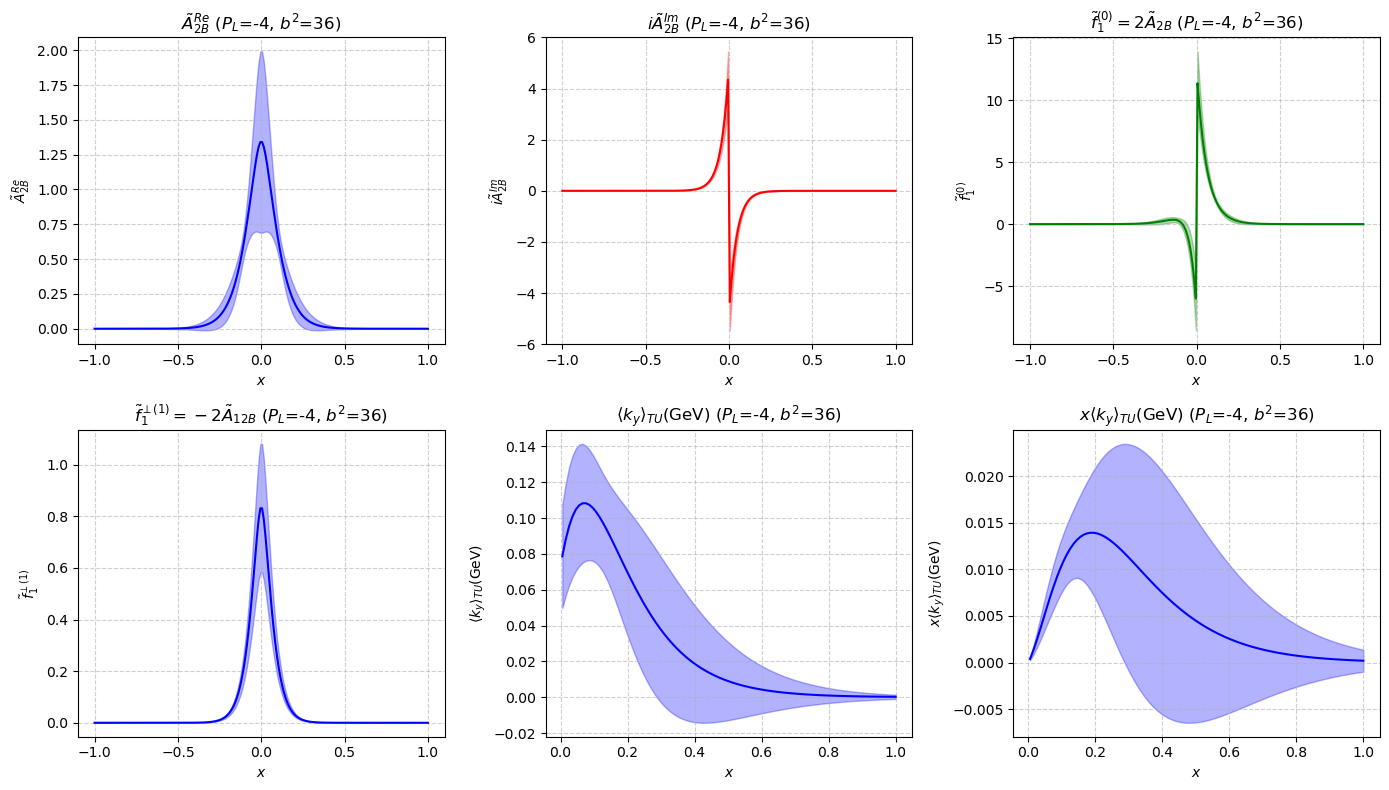

In [7]:
b2 = 36
PL = -4
bminfit = 3
etamin = 6
etamax = 10
fitted_params, chi2_dof_list = load_params_from_h5(f"/Users/hariprashadravikumar/sivers_TMD_PhD_project/save_h5_A12B_A2B/SimultaniousFit/FitParams_SimulFit_f_A2BRe_cetasq_A2BIm_A12BRe_bmin{bminfit}_eta{etamin}{etamax}_PL{PL}.h5")
plot_fourier_transforms_A2B_A12B(fitted_params, chi2_dof_list, b2, PL, bminfit, etamin, etamax)
